# 00 — Reproduction Baseline of the Original Paper

**Topic:** Solar energy forecasting for Errachidia, Morocco  
**Reference paper:** *Prediction of solar energy guided by Pearson correlation using machine learning* — Jebli et al. (2021), Energy 224, 120109.

## Purpose of this notebook

This notebook is the **reproduction-style baseline** of the project.  
It keeps the same general logic as the original simulation notebook:

1. Load NASA POWER data for Errachidia, Morocco.
2. Preprocess and resample to 30-minute intervals.
3. Simulate physical/sensor noise to approximate ground-station behavior.
4. Use Pearson correlation for feature identification.
5. Reproduce three paper-style scenarios:
   - **Scenario 1:** all features including solar radiation, used to check overfitting behavior.
   - **Scenario 2:** Pearson-filtered features for real-time / 30-minute forecasting.
   - **Scenario 3:** Pearson-filtered daily resampled data for daily prediction.
6. Compare LR, SVR, RF, and ANN/MLP using MAE, MSE, RMSE, Max Error, R², and NRMSE.

## 0. Configuration and library imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    max_error,
)

SEED = 42
DATA_PATH = "morocco_data.csv"

np.random.seed(SEED)

print("Libraries loaded successfully.")
print("Input data path:", DATA_PATH)

Libraries loaded successfully.
Input data path: morocco_data.csv


## 1. Load NASA POWER data and construct the 30-minute reproduction dataset

The original paper describes data at a 30-minute step.  
The available NASA POWER data is hourly, so this reproduction-style notebook follows the earlier simulation logic by resampling hourly values to **30-minute intervals** with linear interpolation.

This step is kept for **paper-style reproduction only**.  
The later notebooks use native hourly data for stricter forecasting.

In [2]:
# =========================
# 1. Load data
# =========================

print("=" * 90)
print("1. Loading NASA POWER data for Errachidia, Morocco")
print("=" * 90)

morocco_df = pd.read_csv(DATA_PATH, skiprows=14)

# Convert time columns
time_cols = {"YEAR": "year", "MO": "month", "DY": "day", "HR": "hour"}
morocco_df = morocco_df.rename(columns=time_cols)
morocco_df["time"] = pd.to_datetime(morocco_df[list(time_cols.values())])
morocco_df = morocco_df.drop(columns=list(time_cols.values()))
morocco_df = morocco_df.set_index("time").sort_index()

# Rename variables to paper-style names
morocco_df = morocco_df.rename(columns={
    "ALLSKY_SFC_SW_DWN": "Solar_Radiation",
    "T2M": "Temperature",
    "RH2M": "Humidity",
    "PS": "Pressure",
    "WS10M": "Wind_Speed",
    "WD10M": "Wind_Direction",
})

# Resample hourly NASA POWER data to 30-minute intervals
morocco_df = morocco_df.resample("30min").interpolate(method="linear")

print("Raw 30-minute dataframe shape:", morocco_df.shape)
print("Date range:", morocco_df.index.min(), "→", morocco_df.index.max())
display(morocco_df.head())
display(morocco_df.describe().T)

1. Loading NASA POWER data for Errachidia, Morocco
Raw 30-minute dataframe shape: (52607, 6)
Date range: 2016-01-01 00:00:00 → 2018-12-31 23:00:00


,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation,Temperature
time,,,,,,
2016-01-01 00:00:00,87.96,1.63,235.50,36.480,0.0,8.090
2016-01-01 00:30:00,87.94,1.56,234.60,36.670,0.0,7.985
2016-01-01 01:00:00,87.92,1.49,233.70,36.860,0.0,7.880
2016-01-01 01:30:00,87.90,1.45,233.25,37.055,0.0,7.800
2016-01-01 02:00:00,87.88,1.41,232.80,37.250,0.0,7.720


,count,mean,std,min,25%,50%,75%,max
Pressure,52607.0,87.256597,0.469010,85.59,86.9700,87.300,87.550,88.67
Wind_Speed,52607.0,3.627532,2.223922,0.02,2.0250,3.090,4.800,15.31
Wind_Direction,52607.0,191.230082,111.090545,0.00,104.4000,194.800,296.075,359.90
Humidity,52607.0,41.737426,22.673722,3.23,22.8575,38.485,57.770,100.00
Solar_Radiation,52607.0,245.817257,322.513966,0.00,0.0000,18.175,498.510,1087.40
Temperature,52607.0,17.300363,9.897789,-5.28,9.2700,17.060,24.480,40.61


## 2. Basic preprocessing

This step removes invalid values, fills missing data, and keeps the meteorological variables used in the reproduction.

In [3]:
# =========================
# 2. Basic preprocessing
# =========================

print("=" * 90)
print("2. Basic preprocessing")
print("=" * 90)

morocco_df = morocco_df.replace(-999.0, np.nan)
morocco_df = morocco_df.interpolate(method="linear").ffill().bfill()

initial_features = [
    "Solar_Radiation",
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Wind_Direction",
]

morocco_df = morocco_df[initial_features].copy()

print("Shape after preprocessing:", morocco_df.shape)
print("Total missing values:", morocco_df.isna().sum().sum())
display(morocco_df.head())

2. Basic preprocessing
Shape after preprocessing: (52607, 6)
Total missing values: 0


,Solar_Radiation,Temperature,Humidity,Pressure,Wind_Speed,Wind_Direction
time,,,,,,
2016-01-01 00:00:00,0.0,8.090,36.480,87.96,1.63,235.50
2016-01-01 00:30:00,0.0,7.985,36.670,87.94,1.56,234.60
2016-01-01 01:00:00,0.0,7.880,36.860,87.92,1.49,233.70
2016-01-01 01:30:00,0.0,7.800,37.055,87.90,1.45,233.25
2016-01-01 02:00:00,0.0,7.720,37.250,87.88,1.41,232.80


## 3. Physical noise simulation and target generation

NASA POWER is satellite/reanalysis-based and usually smoother than ground-station measurements.  
To keep the same simulation logic, this step adds:

- sensor noise for temperature, humidity, and pressure;
- random cloud-shading drops for solar radiation during daytime;
- a simple temperature penalty to approximate PV efficiency loss;
- a simulated `Solar_Energy` target in kJ/m².

This target is **simulated**, not measured PV plant production.

In [4]:
# =========================
# 3. Physical noise simulation and target generation
# =========================

print("=" * 90)
print("3. Physical noise simulation and target generation")
print("=" * 90)

np.random.seed(SEED)

# 1. Sensor noise
morocco_df["Temperature"] += np.random.normal(0, 1.5, size=len(morocco_df))
morocco_df["Humidity"] += np.random.normal(0, 3.0, size=len(morocco_df))
morocco_df["Pressure"] += np.random.normal(0, 0.2, size=len(morocco_df))

# 2. Cloud-shading effect
cloud_drops = np.abs(np.random.normal(0, 150, size=len(morocco_df)))
is_cloudy = np.random.choice([0, 1], size=len(morocco_df), p=[0.7, 0.3])

daytime_mask = morocco_df["Solar_Radiation"] > 10
morocco_df.loc[daytime_mask, "Solar_Radiation"] -= (cloud_drops * is_cloudy)[daytime_mask.values]
morocco_df["Solar_Radiation"] = morocco_df["Solar_Radiation"].clip(lower=0)

# 3. Temperature penalty and energy target
temp_penalty = 1 - 0.004 * (morocco_df["Temperature"] - 25).clip(lower=0)

# Energy over 30 minutes:
# Solar energy (J/m²) = irradiance × 1800 seconds × temperature penalty
# Converted to kJ/m²
morocco_df["Solar_Energy"] = morocco_df["Solar_Radiation"] * 1800 * temp_penalty / 1000

cloud_count = int((is_cloudy[daytime_mask.values] == 1).sum())
daytime_count = int(daytime_mask.sum())

print(f"Solar Radiation after noise: min={morocco_df['Solar_Radiation'].min():.2f}, max={morocco_df['Solar_Radiation'].max():.2f}")
print(f"Solar Energy target:         min={morocco_df['Solar_Energy'].min():.2f}, max={morocco_df['Solar_Energy'].max():.2f} kJ/m²")
print(f"Cloud-shading ratio in daytime: {cloud_count}/{daytime_count} ({cloud_count / max(daytime_count, 1) * 100:.2f}%)")
print(f"Pearson r(Radiation, Energy): {morocco_df['Solar_Radiation'].corr(morocco_df['Solar_Energy']):.4f}")

display(morocco_df.head())

3. Physical noise simulation and target generation
Solar Radiation after noise: min=0.00, max=1087.40
Solar Energy target:         min=0.00, max=1910.91 kJ/m²
Cloud-shading ratio in daytime: 8182/27058 (30.24%)
Pearson r(Radiation, Energy): 0.9997


,Solar_Radiation,Temperature,Humidity,Pressure,Wind_Speed,Wind_Direction,Solar_Energy
time,,,,,,,
2016-01-01 00:00:00,0.0,8.835071,34.565942,88.110564,1.63,235.50,0.0
2016-01-01 00:30:00,0.0,7.777604,40.314198,87.903561,1.56,234.60,0.0
2016-01-01 01:00:00,0.0,8.851533,34.114187,88.029614,1.49,233.70,0.0
2016-01-01 01:30:00,0.0,10.084545,32.124556,87.976809,1.45,233.25,0.0
2016-01-01 02:00:00,0.0,7.368770,36.285068,87.754086,1.41,232.80,0.0


## 4. Pearson correlation and paper-style feature selection

The original paper uses Pearson correlation to identify meteorological variables that are most related to solar energy.  
In this reproduction baseline, Pearson is kept as the main feature-identification step.

Wind speed and wind direction are dropped to mimic the paper-style conclusion that they are less meaningful for this forecasting setup.

4. Pearson correlation and feature selection


,Feature,Pearson r with Solar_Energy
0,Solar_Radiation,0.999713
1,Temperature,0.506575
2,Wind_Speed,0.248953
3,Hour,-0.001003
4,Pressure,-0.037100
5,Week,-0.052021
6,Wind_Direction,-0.076771
7,Humidity,-0.555160


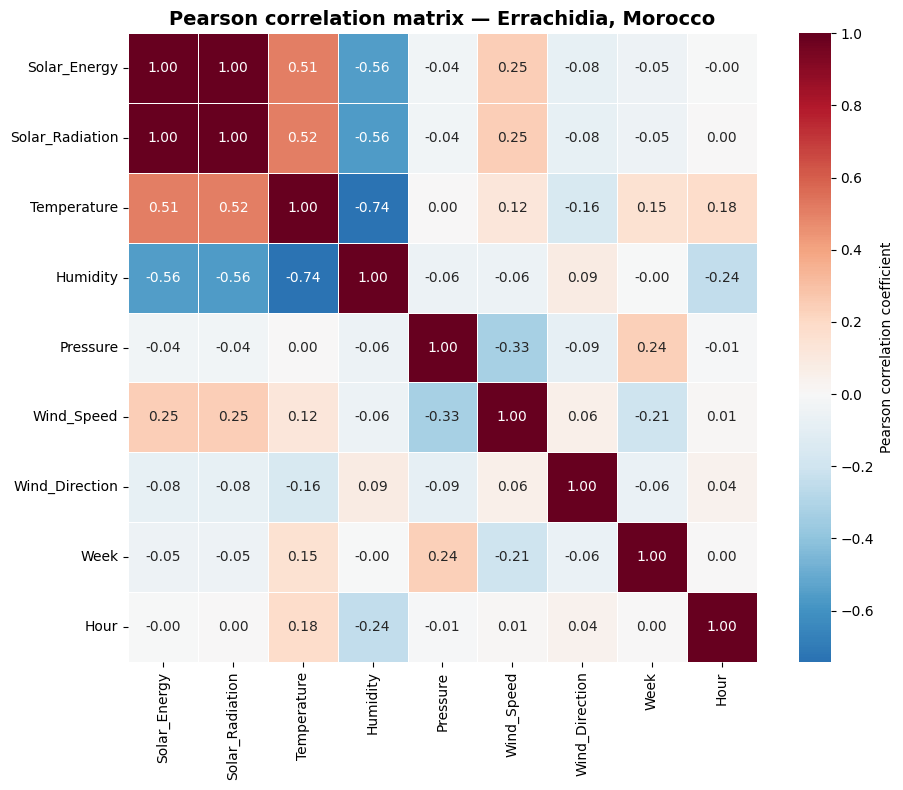

Selected features for Scenario 2 and 3: ['Temperature', 'Humidity', 'Pressure', 'Hour', 'Week']
Features for Scenario 1: ['Solar_Radiation', 'Temperature', 'Humidity', 'Pressure', 'Hour', 'Week']
Target: Solar_Energy


In [5]:
# =========================
# 4. Pearson correlation and feature selection
# =========================

print("=" * 90)
print("4. Pearson correlation and feature selection")
print("=" * 90)

# Time features used in the original reproduction logic
morocco_df["Hour"] = morocco_df.index.hour + morocco_df.index.minute / 60.0
morocco_df["Week"] = morocco_df.index.isocalendar().week.astype(float)

corr_cols = [
    "Solar_Energy",
    "Solar_Radiation",
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Wind_Direction",
    "Week",
    "Hour",
]

corr_matrix = morocco_df[corr_cols].corr()

pearson_se = corr_matrix["Solar_Energy"].drop("Solar_Energy").sort_values(ascending=False)
pearson_table = pearson_se.reset_index()
pearson_table.columns = ["Feature", "Pearson r with Solar_Energy"]

display(pearson_table)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson correlation coefficient"},
)
plt.title("Pearson correlation matrix — Errachidia, Morocco", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Paper-style feature selection
morocco_df = morocco_df.drop(columns=["Wind_Speed", "Wind_Direction"])

features_selected = ["Temperature", "Humidity", "Pressure", "Hour", "Week"]
features_with_radiation = ["Solar_Radiation", "Temperature", "Humidity", "Pressure", "Hour", "Week"]
target_col = "Solar_Energy"

print("Selected features for Scenario 2 and 3:", features_selected)
print("Features for Scenario 1:", features_with_radiation)
print("Target:", target_col)

## 5. Train/test split and scaling

This notebook keeps the reproduction-style **80/20 split** with `shuffle=False`.

- Scenario 1 and 2 use 30-minute data.
- Scenario 3 uses daily mean resampling.


In [6]:
# =========================
# 5. Train/test split and scaling
# =========================

print("=" * 90)
print("5. Train/test split and scaling")
print("=" * 90)

# 5.1 30-minute data for Scenario 1 and Scenario 2
df_train, df_test = train_test_split(morocco_df, test_size=0.2, shuffle=False)

scaler_s2 = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(df_train[features_selected])
X_test_s2 = scaler_s2.transform(df_test[features_selected])

scaler_s1 = StandardScaler()
X_train_s1 = scaler_s1.fit_transform(df_train[features_with_radiation])
X_test_s1 = scaler_s1.transform(df_test[features_with_radiation])

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(df_train[[target_col]]).ravel()
y_test = scaler_y.transform(df_test[[target_col]]).ravel()

# 5.2 Daily data for Scenario 3
morocco_daily = morocco_df.resample("1D").mean()
morocco_daily["Week"] = morocco_daily.index.isocalendar().week.astype(float)

features_daily = ["Temperature", "Humidity", "Pressure", "Week"]

df_daily_train, df_daily_test = train_test_split(morocco_daily, test_size=0.2, shuffle=False)

scaler_s3 = StandardScaler()
X_train_s3 = scaler_s3.fit_transform(df_daily_train[features_daily])
X_test_s3 = scaler_s3.transform(df_daily_test[features_daily])

scaler_y_daily = StandardScaler()
y_train_daily = scaler_y_daily.fit_transform(df_daily_train[[target_col]]).ravel()
y_test_daily = scaler_y_daily.transform(df_daily_test[[target_col]]).ravel()

split_summary = pd.DataFrame([
    {
        "Dataset": "30-minute reproduction data",
        "Train rows": X_train_s2.shape[0],
        "Test rows": X_test_s2.shape[0],
        "Train start": df_train.index.min(),
        "Train end": df_train.index.max(),
        "Test start": df_test.index.min(),
        "Test end": df_test.index.max(),
    },
    {
        "Dataset": "Daily resampled data",
        "Train rows": X_train_s3.shape[0],
        "Test rows": X_test_s3.shape[0],
        "Train start": df_daily_train.index.min(),
        "Train end": df_daily_train.index.max(),
        "Test start": df_daily_test.index.min(),
        "Test end": df_daily_test.index.max(),
    },
])

display(split_summary)
print(f"Solar Energy range in 30-minute train set: {df_train[target_col].min():.2f} — {df_train[target_col].max():.2f} kJ/m²")

5. Train/test split and scaling


,Dataset,Train rows,Test rows,Train start,Train end,Test start,Test end
0,30-minute reproduction data,42085,10522,2016-01-01,2018-05-26 18:00:00,2018-05-26 18:30:00,2018-12-31 23:00:00
1,Daily resampled data,876,220,2016-01-01,2018-05-25 00:00:00,2018-05-26 00:00:00,2018-12-31 00:00:00


Solar Energy range in 30-minute train set: 0.00 — 1910.91 kJ/m²


## 6. Model definitions and evaluation functions

The four models follow the reproduction logic:

- Linear Regression
- SVR with RBF kernel
- Random Forest
- ANN/MLP with the paper-inspired hidden-layer structure

In [7]:
# =========================
# 6. Model definitions and evaluation functions
# =========================

def create_models():
    """Create paper-style models for Scenario 1 and Scenario 2."""
    return {
        "Linear Regression (LR)": LinearRegression(),
        "SVR (RBF Kernel)": SVR(kernel="rbf", C=1, gamma="scale"),
        "Random Forest (RF)": RandomForestRegressor(
            n_estimators=100,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=SEED,
            n_jobs=-1,
        ),
        "ANN (MLP)": MLPRegressor(
            hidden_layer_sizes=(100, 200, 300, 50, 25, 10, 5),
            activation="relu",
            solver="adam",
            batch_size=32,
            max_iter=500,
            random_state=1,
            learning_rate="adaptive",
            learning_rate_init=0.001,
        ),
    }


def create_models_daily():
    """Create paper-style models for Scenario 3."""
    return {
        "Linear Regression (LR)": LinearRegression(),
        "SVR (RBF Kernel)": SVR(kernel="rbf", C=1, gamma="scale"),
        "Random Forest (RF)": RandomForestRegressor(
            n_estimators=100,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=SEED,
            n_jobs=-1,
        ),
        "ANN (MLP)": MLPRegressor(
            hidden_layer_sizes=(100, 200, 300, 50, 25, 10, 5),
            activation="relu",
            solver="adam",
            batch_size=1,
            max_iter=1000,
            random_state=1,
            learning_rate="adaptive",
            learning_rate_init=0.001,
        ),
    }


def evaluate_regression(y_true, y_pred):
    """Return regression metrics in the original target unit."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    me = max_error(y_true, y_pred)

    y_range = max(float(np.max(y_true) - np.min(y_true)), 1e-9)
    nrmse = rmse / y_range

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "Max Error": me,
        "R² (%)": r2 * 100,
    }


def run_scenario(X_train, y_train_scaled, X_test, y_test_scaled, y_scaler, models, scenario_name):
    """Train models and evaluate them after inverse-transforming the target."""
    print("\n" + "=" * 90)
    print(scenario_name)
    print("=" * 90)

    y_test_original = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

    rows = []

    for model_name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train_scaled)
        elapsed = time.time() - start

        y_pred_scaled = model.predict(X_test)
        y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

        metrics = evaluate_regression(y_test_original, y_pred)

        row = {
            "Model": model_name,
            **metrics,
            "Train Time (s)": elapsed,
        }
        rows.append(row)

        print(
            f"{model_name:<24s} | "
            f"R²={metrics['R² (%)']:>8.2f}% | "
            f"RMSE={metrics['RMSE']:>10.2f} kJ/m² | "
            f"Time={elapsed:>7.2f}s"
        )

    results = pd.DataFrame(rows)

    results["MAE"] = results["MAE"].round(2)
    results["MSE"] = results["MSE"].round(2)
    results["RMSE"] = results["RMSE"].round(2)
    results["NRMSE"] = results["NRMSE"].round(4)
    results["Max Error"] = results["Max Error"].round(2)
    results["R² (%)"] = results["R² (%)"].round(2)
    results["Train Time (s)"] = results["Train Time (s)"].round(2)

    return results

## 7. Run the three reproduction scenarios

In [8]:
# =========================
# 7. Run reproduction scenarios
# =========================

res_s1 = run_scenario(
    X_train_s1,
    y_train,
    X_test_s1,
    y_test,
    scaler_y,
    create_models(),
    "Scenario 1 — All features including solar radiation",
)

res_s2 = run_scenario(
    X_train_s2,
    y_train,
    X_test_s2,
    y_test,
    scaler_y,
    create_models(),
    "Scenario 2 — Pearson-filtered 30-minute real-time prediction",
)

res_s3 = run_scenario(
    X_train_s3,
    y_train_daily,
    X_test_s3,
    y_test_daily,
    scaler_y_daily,
    create_models_daily(),
    "Scenario 3 — Pearson-filtered daily resampled prediction",
)


Scenario 1 — All features including solar radiation
Linear Regression (LR)   | R²=   99.94% | RMSE=     13.33 kJ/m² | Time=   0.00s
SVR (RBF Kernel)         | R²=   99.84% | RMSE=     21.72 kJ/m² | Time=   0.66s
Random Forest (RF)       | R²=  100.00% | RMSE=      1.77 kJ/m² | Time=   1.19s
ANN (MLP)                | R²=  100.00% | RMSE=      3.64 kJ/m² | Time= 160.56s

Scenario 2 — Pearson-filtered 30-minute real-time prediction
Linear Regression (LR)   | R²=   32.10% | RMSE=    446.42 kJ/m² | Time=   0.00s
SVR (RBF Kernel)         | R²=   89.63% | RMSE=    174.44 kJ/m² | Time=  30.59s
Random Forest (RF)       | R²=   93.55% | RMSE=    137.58 kJ/m² | Time=   1.05s
ANN (MLP)                | R²=   94.16% | RMSE=    130.97 kJ/m² | Time=5693.79s

Scenario 3 — Pearson-filtered daily resampled prediction
Linear Regression (LR)   | R²=   67.10% | RMSE=     70.64 kJ/m² | Time=   0.00s
SVR (RBF Kernel)         | R²=   78.91% | RMSE=     56.56 kJ/m² | Time=   0.02s
Random Forest (RF)       | 

## 8. Results and paper-style comparison

In [9]:
# =========================
# 8. Display scenario results
# =========================

def display_result_table(df, caption):
    styled = (
        df.style
        .background_gradient(cmap="RdYlGn", subset=["R² (%)"])
        .background_gradient(cmap="RdYlGn_r", subset=["RMSE", "MAE"])
        .format(precision=2)
        .set_caption(caption)
    )
    display(styled)


display(Markdown("### Scenario 1 — Overfitting check"))
display(Markdown("""
**Description:** uses all variables, including `Solar_Radiation`.

In the original paper, the all-variable scenario produced extremely high R² values.
This is discussed as a symptom of overfitting / overly direct dependence between input radiation and energy.
"""))
display_result_table(res_s1, "Scenario 1 metrics — All features")


display(Markdown("### Scenario 2 — Real-time 30-minute prediction"))
display(Markdown("""
**Description:** uses Pearson-filtered variables only.

Original paper reference values for Morocco Scenario 2:

| Model | MAE | MSE | RMSE | Max Error | R² |
|---|---:|---:|---:|---:|---:|
| LR | 9.30 | 128.72 | 11.34 | 41.77 | 22.05% |
| RF | 1.47 | 8.45 | 2.90 | 25.97 | 94.81% |
| SVR | 5.92 | 61.05 | 7.81 | 35.10 | 62.62% |
| ANN | 1.94 | 12.19 | 3.49 | 29.40 | 92.61% |
"""))
display_result_table(res_s2, "Scenario 2 metrics — Real-time 30-minute")


display(Markdown("### Scenario 3 — Daily resampled prediction"))
display(Markdown("""
**Description:** uses daily mean resampling and Pearson-filtered variables.

Original paper reference values for Morocco Scenario 3:

| Model | MAE | MSE | RMSE | Max Error | R² |
|---|---:|---:|---:|---:|---:|
| LR | 79.20 | 24292.99 | 155.86 | 1345.74 | 31% |
| RF | 67.33 | 9399.16 | 96.94 | 483.50 | 58% |
| SVR | 77.74 | 11919.53 | 109.17 | 551.13 | 44% |
| ANN | 30.30 | 1980.24 | 44.49 | 245.72 | 93% |
"""))
display_result_table(res_s3, "Scenario 3 metrics — Daily resampled")

### Scenario 1 — Overfitting check


**Description:** uses all variables, including `Solar_Radiation`.

In the original paper, the all-variable scenario produced extremely high R² values.
This is discussed as a symptom of overfitting / overly direct dependence between input radiation and energy.


,Model,MAE,MSE,RMSE,NRMSE,Max Error,R² (%),Train Time (s)
0,Linear Regression (LR),8.98,177.62,13.33,0.01,84.16,99.94,0.00
1,SVR (RBF Kernel),17.55,471.83,21.72,0.01,138.92,99.84,0.66
2,Random Forest (RF),0.49,3.14,1.77,0.00,51.25,100.00,1.19
3,ANN (MLP),2.23,13.25,3.64,0.00,19.18,100.00,160.56


### Scenario 2 — Real-time 30-minute prediction


**Description:** uses Pearson-filtered variables only.

Original paper reference values for Morocco Scenario 2:

| Model | MAE | MSE | RMSE | Max Error | R² |
|---|---:|---:|---:|---:|---:|
| LR | 9.30 | 128.72 | 11.34 | 41.77 | 22.05% |
| RF | 1.47 | 8.45 | 2.90 | 25.97 | 94.81% |
| SVR | 5.92 | 61.05 | 7.81 | 35.10 | 62.62% |
| ANN | 1.94 | 12.19 | 3.49 | 29.40 | 92.61% |


,Model,MAE,MSE,RMSE,NRMSE,Max Error,R² (%),Train Time (s)
0,Linear Regression (LR),355.89,199289.70,446.42,0.23,1275.91,32.10,0.00
1,SVR (RBF Kernel),118.90,30428.81,174.44,0.09,877.64,89.63,30.59
2,Random Forest (RF),72.70,18928.12,137.58,0.07,947.54,93.55,1.05
3,ANN (MLP),71.21,17152.82,130.97,0.07,1001.20,94.16,5693.79


### Scenario 3 — Daily resampled prediction


**Description:** uses daily mean resampling and Pearson-filtered variables.

Original paper reference values for Morocco Scenario 3:

| Model | MAE | MSE | RMSE | Max Error | R² |
|---|---:|---:|---:|---:|---:|
| LR | 79.20 | 24292.99 | 155.86 | 1345.74 | 31% |
| RF | 67.33 | 9399.16 | 96.94 | 483.50 | 58% |
| SVR | 77.74 | 11919.53 | 109.17 | 551.13 | 44% |
| ANN | 30.30 | 1980.24 | 44.49 | 245.72 | 93% |


,Model,MAE,MSE,RMSE,NRMSE,Max Error,R² (%),Train Time (s)
0,Linear Regression (LR),53.89,4989.70,70.64,0.13,236.62,67.10,0.00
1,SVR (RBF Kernel),43.24,3199.40,56.56,0.10,255.84,78.91,0.02
2,Random Forest (RF),49.47,4042.05,63.58,0.12,214.12,73.35,0.13
3,ANN (MLP),44.38,3290.24,57.36,0.11,238.74,78.31,218.19


## 9. NRMSE synthesis

This table summarizes the two main horizons emphasized in the original reproduction logic:

- 30-minute real-time prediction
- daily resampled prediction

In [10]:
# =========================
# 9. NRMSE synthesis
# =========================

summary_rows = []

for model_name in res_s2["Model"]:
    rt_row = res_s2.loc[res_s2["Model"] == model_name].iloc[0]
    daily_row = res_s3.loc[res_s3["Model"] == model_name].iloc[0]

    summary_rows.append({
        "Model": model_name,
        "NRMSE (Real-time)": rt_row["NRMSE"],
        "NRMSE (Daily)": daily_row["NRMSE"],
        "Train Time RT (s)": rt_row["Train Time (s)"],
        "Train Time Daily (s)": daily_row["Train Time (s)"],
    })

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df.style
    .background_gradient(cmap="RdYlGn_r", subset=["NRMSE (Real-time)", "NRMSE (Daily)"])
    .format(precision=4)
    .set_caption("NRMSE and training time synthesis")
)

,Model,NRMSE (Real-time),NRMSE (Daily),Train Time RT (s),Train Time Daily (s)
0,Linear Regression (LR),0.2338,0.1307,0.0000,0.0000
1,SVR (RBF Kernel),0.0914,0.1047,30.5900,0.0200
2,Random Forest (RF),0.0721,0.1177,1.0500,0.1300
3,ANN (MLP),0.0686,0.1062,5693.7900,218.1900


## 10. Interpretation

This notebook should be used as the **Notebook 00 reproduction baseline**.

Important points for the report:

1. The notebook follows the original paper's broad workflow: preprocessing → Pearson correlation → LR/RF/SVR/ANN → multiple scenarios.
2. Results may not match the paper exactly because the original dataset is not publicly available and this notebook uses NASA POWER plus simulated physical noise.
3. The daily scenario here is a reproduction-style daily resampling experiment, not the stricter `next-day daily total` experiment developed later.
4. The modernized notebooks improve the methodology by using native hourly data, time-based splits, lag/rolling/cyclic features, pvlib features, boosting models, deep learning backbones, ensemble learning, and extended 20-year daily data.